**importeer de libraries**

In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_percentage_error

C:\Users\lande\AppData\Local\Temp\ipykernel_1736\500858203.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


**Model**

In [2]:
train_data = pd.read_csv("d://HHS//Deep Learning//Portfolio opdracht 1//new_train.csv")
test_data = pd.read_csv("d://HHS//Deep Learning//Portfolio opdracht 1//test.csv") 

X = train_data.drop(['Price'], axis=1)
y = train_data['Price']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_val, y_train, y_val = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

model = keras.Sequential([
    layers.Dense(256, activation='relu', input_shape=(X.shape[1],)),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dense(1) 
])

#Optimizer
optimizer = keras.optimizers.RMSprop(learning_rate=0.001)

#Model
model.compile(optimizer=optimizer, loss='mean_absolute_percentage_error')

#Early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

#Train het model
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_val, y_val), callbacks=[early_stopping])

#Standariseren 
X_test_scaled = scaler.transform(test_data)

# Voorspelling van prijzen op de test gegevens
predictions = model.predict(X_test_scaled)
print(predictions)

C:\Users\lande\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\core\dense.py:85: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 99.9990 - val_loss: 99.8655
Epoch 2/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 889us/step - loss: 94.7399 - val_loss: 77.2891
Epoch 3/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 929us/step - loss: 73.8910 - val_loss: 56.8997
Epoch 4/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 875us/step - loss: 51.1151 - val_loss: 41.8846
Epoch 5/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 862us/step - loss: 42.2255 - val_loss: 38.6265
Epoch 6/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 889us/step - loss: 40.2087 - val_loss: 37.8059
Epoch 7/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 892us/step - loss: 39.7885 - val_loss: 37.5195
Epoch 8/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 854us/step - loss: 39.0954 - val_loss: 37.1917
Epoch 9/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 874us/step - loss: 38.9147 - val_loss: 36.6363
Epoch 10/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 887us/step - loss: 38.0901 - val_loss: 36.3259
Epoch 11/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 870us/step - loss: 38.0626 - val_loss: 36.0014
Epoch 12/5

**Visualisatie**

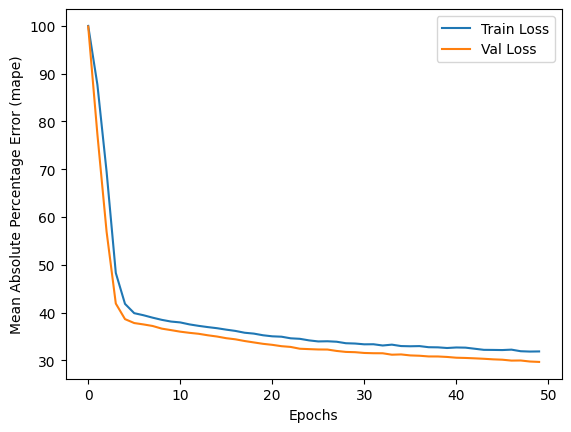

In [3]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Percentage Error (mape)')
plt.legend()
plt.show()